# VQA Múa Lân — Train & Eval (C1)

**C1**: Transformer Decoder (SwiGLU + RMSNorm) + BBox-Enhanced Image Encoder

| Module | Thành phần |
|--------|------------|
| **Image Encoder** | SigLIP2-B/16 (layer −2, frozen) → img_proj → **CBAM** (Channel + Spatial Attn) |
| **BBox Encoder** | RoI Pool từ patch grid 14×14 → bbox_proj + **class_embed** → Bottom-Up tokens |
| **Question Encoder** | PhoBERT-v2 (mean 4 last layers, frozen) — *không thay đổi* |
| **Fusion** | CrossAttentionFusion: text(Q) × [patch ‖ bbox tokens](KV) |
| **Decoder (C1)** | Transformer + **RMSNorm** + **SwiGLU** |

### Tham khảo:
- **Bottom-Up and Top-Down Attention** (Anderson et al., CVPR 2018)
- **CBAM** (Woo et al., ECCV 2018)

### BBox classes:
| Lớp | Index |
|-----|-------|
| pad | 0 |
| con lân | 1 |
| người biểu diễn | 2 |

**Pipeline cache**:
- `img_feats / txt_feats / ans_*` → load từ `output/cache/` (tái sử dụng, không encode lại)
- `bbox_feats / bbox_masks / bbox_class_ids` → compute thêm bằng numpy RoI, lưu vào `cache_bbox/`
- Trên Kaggle: `output/` → `/kaggle/input/datasets/namkhn/qa-domain-bbox/`

## 0. Kaggle Setup

In [1]:
!git clone https://github.com/KhanhNamYeh/qa-domain

Cloning into 'qa-domain'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 137 (delta 66), reused 101 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 1.18 MiB | 8.66 MiB/s, done.
Resolving deltas: 100% (66/66), done.


In [2]:
!pwd
!ls

/kaggle/working
__notebook__.ipynb  qa-domain


In [3]:
!pip install pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.9 MB/s eta 0:00:00


## 1. Setup

In [4]:
import os, sys, time, json, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

_ON_KAGGLE = os.path.isdir('/kaggle/working')

# qa-domain repo root (contains src/)
PROJECT_ROOT = (
    '/kaggle/working/qa-domain'
    if os.path.isdir('/kaggle/working/qa-domain')
    else os.path.abspath('')          # local: notebook directory
)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Writable working directory
WORKSPACE_DIR = '/kaggle/working' if _ON_KAGGLE else os.path.join(os.path.abspath(''), 'output')

# Read-only dataset input:
#   Kaggle  → /kaggle/input/datasets/namkhn/qa-domain-bbox
#   Local   → output/   (same folder as notebook)
_KAGGLE_DS = '/kaggle/input/datasets/namkhn/qa-domain-bbox'
DATASET_DIR = _KAGGLE_DS if os.path.isdir(_KAGGLE_DS) else os.path.join(os.path.abspath(''), 'output')

from src.config import ModelConfig, TrainConfig
from src.build import resolve_special_ids
from src.training import Trainer, Evaluator
from src.metrics import ExactMatch, BLEUScore, METEORScore
from src.models import CrossAttentionFusion, RMSNorm, SwiGLU
from src.models.decoders import TransformerDecoder
from src.data.vi_segment import segment as vi_segment

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('project_root  =', PROJECT_ROOT)
print('workspace_dir =', WORKSPACE_DIR)
print('dataset_dir   =', DATASET_DIR)
print('device        =', DEVICE)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

project_root  = /kaggle/working/qa-domain
workspace_dir = /kaggle/working
dataset_dir   = /kaggle/input/datasets/namkhn/qa-domain-bbox
device        = cuda


## 1.5. Pretrained models

Ưu tiên load từ `DATASET_DIR/pretrained/` (đã có sẵn, không cần download).  
Fallback: download từ HuggingFace vào `WORKSPACE_DIR/pretrained/` nếu chưa có.

In [5]:
from transformers import AutoModel, AutoImageProcessor

def _has_local(path):
    return os.path.isdir(path) and os.path.exists(os.path.join(path, 'config.json'))

_DS_PRETRAINED  = os.path.join(DATASET_DIR,   'pretrained')
_WS_PRETRAINED  = os.path.join(WORKSPACE_DIR, 'pretrained')
os.makedirs(_WS_PRETRAINED, exist_ok=True)

SIGLIP_HF  = 'google/siglip2-base-patch16-224'
PHOBERT_HF = 'vinai/phobert-base-v2'

def _resolve_pretrained(name, hf_id, is_siglip=False):
    """Return local path for a pretrained model, downloading if needed."""
    ds_path = os.path.join(_DS_PRETRAINED, name)
    ws_path = os.path.join(_WS_PRETRAINED, name)
    if _has_local(ds_path):
        print(f'[{name}] loaded from dataset  -> {ds_path}')
        return ds_path
    if _has_local(ws_path):
        print(f'[{name}] loaded from workspace -> {ws_path}')
        return ws_path
    print(f'[{name}] downloading from HuggingFace -> {ws_path}')
    _m = AutoModel.from_pretrained(hf_id)
    _m.save_pretrained(ws_path)
    if is_siglip:
        AutoImageProcessor.from_pretrained(hf_id).save_pretrained(ws_path)
    else:
        AutoTokenizer.from_pretrained(hf_id, use_fast=False).save_pretrained(ws_path)
    del _m
    return ws_path

SIGLIP_LOCAL  = _resolve_pretrained('siglip2-base-patch16-224', SIGLIP_HF,  is_siglip=True)
PHOBERT_LOCAL = _resolve_pretrained('phobert-base-v2',          PHOBERT_HF, is_siglip=False)

tokenizer = AutoTokenizer.from_pretrained(PHOBERT_LOCAL, use_fast=False)
print('tokenizer loaded from', PHOBERT_LOCAL)

[siglip2-base-patch16-224] loaded from dataset  -> /kaggle/input/datasets/namkhn/qa-domain-bbox/pretrained/siglip2-base-patch16-224
[phobert-base-v2] loaded from dataset  -> /kaggle/input/datasets/namkhn/qa-domain-bbox/pretrained/phobert-base-v2
tokenizer loaded from /kaggle/input/datasets/namkhn/qa-domain-bbox/pretrained/phobert-base-v2


## 1.6. Precompute bbox features (tái sử dụng cache sẵn có)

**Không chạy lại SigLIP / PhoBERT.**  
Tải `img_feats.npy` đã có từ `DATASET_DIR/cache/{split}/`, tính RoI-pool bbox bằng numpy thuần.  
Chỉ lưu thêm 3 file nhỏ vào `WORKSPACE_DIR/cache_bbox/{split}/`:

| File | Shape | Mô tả |
|------|-------|-------|
| `bbox_feats.npy` | (N, K, 768) | RoI-pooled patch features per bbox slot |
| `bbox_masks.npy` | (N, K) | 1 = valid bbox, 0 = padding |
| `bbox_class_ids.npy` | (N, K) | class index (0=pad, 1=con lân, 2=người biểu diễn) |

`img_feats / txt_feats / ans_*` vẫn đọc trực tiếp từ `DATASET_DIR/cache/` (không copy).

In [6]:
BBOX_CLASSES  = ['con lân', 'người biểu diễn']
N_BBOX_CLASSES = len(BBOX_CLASSES)   # 2; index 0 reserved for padding
_CLASS2IDX    = {c: i + 1 for i, c in enumerate(BBOX_CLASSES)}


def _roi_pool_patches(patch_feats: np.ndarray, bbox: list, grid_size: int = 14) -> np.ndarray:
    """Mean-pool SigLIP patch features within normalized bbox [x1,y1,x2,y2].

    Anderson et al. (CVPR 2018): salient region features via spatial pooling.
    """
    x1, y1, x2, y2 = bbox
    c1 = max(0, int(x1 * grid_size))
    r1 = max(0, int(y1 * grid_size))
    c2 = min(grid_size, math.ceil(x2 * grid_size))
    r2 = min(grid_size, math.ceil(y2 * grid_size))
    c2, r2 = max(c2, c1 + 1), max(r2, r1 + 1)
    c2, r2 = min(c2, grid_size), min(r2, grid_size)
    idx = [r * grid_size + c for r in range(r1, r2) for c in range(c1, c2)]
    return patch_feats[idx].mean(axis=0) if idx else patch_feats.mean(axis=0)


def precompute_bbox_only(
    bbox_json_path: str,
    src_cache_dir: str,
    bbox_out_dir: str,
    *,
    max_bbox: int = 10,
    grid_size: int = 14,
    bbox_classes=None,
) -> None:
    """Compute bbox RoI features from existing img_feats cache (pure numpy, no GPU).

    Reads : src_cache_dir/img_feats.npy  (already precomputed)
    Writes: bbox_out_dir/bbox_feats.npy
            bbox_out_dir/bbox_masks.npy
            bbox_out_dir/bbox_class_ids.npy
            bbox_out_dir/meta.json
    """
    if bbox_classes is None:
        bbox_classes = BBOX_CLASSES
    class2idx = {c: i + 1 for i, c in enumerate(bbox_classes)}

    # Load existing cache metadata
    with open(os.path.join(src_cache_dir, 'meta.json'), 'r', encoding='utf-8') as f:
        base_meta = json.load(f)
    with open(os.path.join(src_cache_dir, 'raw.json'), 'r', encoding='utf-8') as f:
        base_raw = json.load(f)

    N              = base_meta['n_samples']
    img_hidden_dim = base_meta['image_hidden_dim']
    save_dtype     = base_meta.get('save_dtype', 'float16')
    np_dtype       = np.float16 if save_dtype == 'float16' else np.float32

    # Load bbox annotations from qa_data_bbox JSON
    with open(bbox_json_path, 'r', encoding='utf-8') as f:
        samples = json.load(f)

    if len(samples) != N:
        raise ValueError(
            f'Sample count mismatch: qa_data_bbox={len(samples)}, cache={N}. '
            'Make sure qa_data_bbox and qa_data have the same samples in the same order.'
        )

    # Soft order-check on first 5 samples
    for i, (s, r) in enumerate(zip(samples[:5], base_raw[:5])):
        if s['question'].strip() != r['question'].strip():
            raise ValueError(
                f'Sample {i} question mismatch — qa_data_bbox and cache may be out of order.\n'
                f'  bbox JSON : {s["question"][:80]}\n'
                f'  cache raw : {r["question"][:80]}'
            )

    # Memory-map img_feats (read-only, no copy)
    img_feats = np.load(os.path.join(src_cache_dir, 'img_feats.npy'), mmap_mode='r')

    bbox_feats_arr = np.zeros((N, max_bbox, img_hidden_dim), dtype=np_dtype)
    bbox_masks_arr = np.zeros((N, max_bbox),                 dtype=np.int64)
    bbox_class_arr = np.zeros((N, max_bbox),                 dtype=np.int64)

    for i, s in enumerate(samples):
        if 'bbox' not in s:
            continue
        patch_feats = np.array(img_feats[i], dtype=np.float32)  # materialise (196, C)
        slot = 0
        for cls_name, box_list in s['bbox'].items():
            for box in box_list:
                if slot >= max_bbox:
                    break
                roi = _roi_pool_patches(patch_feats, box, grid_size)
                bbox_feats_arr[i, slot] = roi.astype(np_dtype)
                bbox_masks_arr[i, slot] = 1
                bbox_class_arr[i, slot] = class2idx.get(cls_name, 0)
                slot += 1
            if slot >= max_bbox:
                break
        if (i + 1) % 2000 == 0:
            print(f'  [{i+1}/{N}]', end='\r')

    os.makedirs(bbox_out_dir, exist_ok=True)
    np.save(os.path.join(bbox_out_dir, 'bbox_feats.npy'),     bbox_feats_arr)
    np.save(os.path.join(bbox_out_dir, 'bbox_masks.npy'),     bbox_masks_arr)
    np.save(os.path.join(bbox_out_dir, 'bbox_class_ids.npy'), bbox_class_arr)
    with open(os.path.join(bbox_out_dir, 'meta.json'), 'w', encoding='utf-8') as f:
        json.dump({
            **base_meta,
            'max_bbox': max_bbox, 'grid_size': grid_size,
            'bbox_classes': bbox_classes,
            'bbox_class_map': {c: i + 1 for i, c in enumerate(bbox_classes)},
        }, f, ensure_ascii=False, indent=2)
    print(f'\n  saved -> {bbox_out_dir}')


def is_cached_bbox(bbox_dir: str) -> bool:
    """True when bbox-specific cache files exist in bbox_dir."""
    must = ['bbox_feats.npy', 'bbox_masks.npy', 'bbox_class_ids.npy', 'meta.json']
    return all(os.path.exists(os.path.join(bbox_dir, f)) for f in must)

In [7]:
# qa_data_bbox JSON — has 'bbox' field per sample
TRAIN_JSON_BBOX = os.path.join(PROJECT_ROOT, 'qa_data_bbox', 'train.json')
VAL_JSON_BBOX   = os.path.join(PROJECT_ROOT, 'qa_data_bbox', 'val.json')
TEST_JSON_BBOX  = os.path.join(PROJECT_ROOT, 'qa_data_bbox', 'test.json')

# Base cache: img/txt/ans already precomputed (read-only)
SRC_CACHE_ROOT = os.path.join(DATASET_DIR, 'cache')

# BBox cache: only bbox_feats/masks/class_ids (writable)
CACHE_ROOT_BBOX = os.path.join(WORKSPACE_DIR, 'cache_bbox')
os.makedirs(CACHE_ROOT_BBOX, exist_ok=True)

MAX_Q_LEN = 32
MAX_A_LEN = 64
MAX_BBOX  = 10
GRID_SIZE = 14   # SigLIP2-B/16: 14×14 = 196 patches

for split, jp in [('train', TRAIN_JSON_BBOX), ('val', VAL_JSON_BBOX), ('test', TEST_JSON_BBOX)]:
    bbox_out = os.path.join(CACHE_ROOT_BBOX, split)
    if is_cached_bbox(bbox_out):
        print(f'[{split}] bbox cache OK -> {bbox_out}')
        continue
    src = os.path.join(SRC_CACHE_ROOT, split)
    print(f'[{split}] computing bbox RoI from {src} ...')
    precompute_bbox_only(
        bbox_json_path=jp,
        src_cache_dir=src,
        bbox_out_dir=bbox_out,
        max_bbox=MAX_BBOX,
        grid_size=GRID_SIZE,
    )

print()
print('SRC_CACHE_ROOT  =', SRC_CACHE_ROOT)
print('CACHE_ROOT_BBOX =', CACHE_ROOT_BBOX)

[train] computing bbox RoI from /kaggle/input/datasets/namkhn/qa-domain-bbox/cache/train ...
  [8000/9879]
  saved -> /kaggle/working/cache_bbox/train
[val] computing bbox RoI from /kaggle/input/datasets/namkhn/qa-domain-bbox/cache/val ...

  saved -> /kaggle/working/cache_bbox/val
[test] computing bbox RoI from /kaggle/input/datasets/namkhn/qa-domain-bbox/cache/test ...

  saved -> /kaggle/working/cache_bbox/test

SRC_CACHE_ROOT  = /kaggle/input/datasets/namkhn/qa-domain-bbox/cache
CACHE_ROOT_BBOX = /kaggle/working/cache_bbox


## 2. BBox Cached DataLoaders

In [8]:
class BBoxCachedVQADataset(Dataset):
    """Load img/txt/ans from base_cache_dir (dataset input) +
    bbox_feat/mask/cls from bbox_cache_dir (workspace).

    Không copy dữ liệu lớn — hai thư mục đọc độc lập qua mmap.
    """

    def __init__(self, base_cache_dir: str, bbox_cache_dir: str):
        # Standard features (base cache, potentially read-only)
        self.img     = np.load(os.path.join(base_cache_dir, 'img_feats.npy'),  mmap_mode='r')
        self.txt     = np.load(os.path.join(base_cache_dir, 'txt_feats.npy'),  mmap_mode='r')
        self.mask    = np.load(os.path.join(base_cache_dir, 'txt_masks.npy'),  mmap_mode='r')
        self.ans_in  = np.load(os.path.join(base_cache_dir, 'ans_ins.npy'),    mmap_mode='r')
        self.ans_out = np.load(os.path.join(base_cache_dir, 'ans_outs.npy'),   mmap_mode='r')
        with open(os.path.join(base_cache_dir, 'raw.json'),  'r', encoding='utf-8') as f:
            self.raw  = json.load(f)
        with open(os.path.join(base_cache_dir, 'meta.json'), 'r', encoding='utf-8') as f:
            self.meta = json.load(f)

        # BBox features (bbox cache, workspace)
        self.bbox     = np.load(os.path.join(bbox_cache_dir, 'bbox_feats.npy'),     mmap_mode='r')
        self.bbox_msk = np.load(os.path.join(bbox_cache_dir, 'bbox_masks.npy'),     mmap_mode='r')
        self.bbox_cls = np.load(os.path.join(bbox_cache_dir, 'bbox_class_ids.npy'), mmap_mode='r')
        with open(os.path.join(bbox_cache_dir, 'meta.json'), 'r', encoding='utf-8') as f:
            self.bbox_meta = json.load(f)

    def __len__(self):
        return len(self.img)

    def __getitem__(self, i):
        return {
            'img_feat':    torch.from_numpy(np.array(self.img[i],     dtype=np.float32, copy=True)),
            'txt_feat':    torch.from_numpy(np.array(self.txt[i],     dtype=np.float32, copy=True)),
            'txt_mask':    torch.from_numpy(np.array(self.mask[i],    dtype=np.int64,   copy=True)),
            'answer_in':   torch.from_numpy(np.array(self.ans_in[i],  dtype=np.int64,   copy=True)),
            'answer_out':  torch.from_numpy(np.array(self.ans_out[i], dtype=np.int64,   copy=True)),
            'bbox_feat':   torch.from_numpy(np.array(self.bbox[i],    dtype=np.float32, copy=True)),
            'bbox_mask':   torch.from_numpy(np.array(self.bbox_msk[i],dtype=np.int64,   copy=True)),
            'bbox_cls':    torch.from_numpy(np.array(self.bbox_cls[i],dtype=np.int64,   copy=True)),
            'raw_question': self.raw[i]['question'],
            'raw_answer':   self.raw[i]['answer'],
        }


class BBoxCachedVQACollator:
    _TENSOR_KEYS = [
        'img_feat', 'txt_feat', 'txt_mask', 'answer_in', 'answer_out',
        'bbox_feat', 'bbox_mask', 'bbox_cls',
    ]

    def __call__(self, batch):
        out = {
            'raw_questions': [b['raw_question'] for b in batch],
            'raw_answers':   [b['raw_answer']   for b in batch],
        }
        for k in self._TENSOR_KEYS:
            if k in batch[0]:
                out[k] = torch.stack([b[k] for b in batch], dim=0)
        return out


def build_bbox_cached_loaders(base_cache_root: str, bbox_cache_root: str, train_cfg):
    """Build DataLoader trio reading from two separate cache roots."""
    collator = BBoxCachedVQACollator()
    datasets = [
        BBoxCachedVQADataset(
            os.path.join(base_cache_root, s),
            os.path.join(bbox_cache_root, s),
        )
        for s in ('train', 'val', 'test')
    ]
    common = dict(num_workers=train_cfg.num_workers, collate_fn=collator, pin_memory=True)
    return (
        DataLoader(datasets[0], batch_size=train_cfg.batch_size, shuffle=True,  **common),
        DataLoader(datasets[1], batch_size=train_cfg.batch_size, shuffle=False, **common),
        DataLoader(datasets[2], batch_size=train_cfg.batch_size, shuffle=False, **common),
    )

In [9]:
_probe_cfg = ModelConfig(
    image_encoder_name=SIGLIP_LOCAL,
    text_encoder_name=PHOBERT_LOCAL,
    max_answer_len=MAX_A_LEN,
)
_probe_cfg = resolve_special_ids(tokenizer, _probe_cfg)

BATCH_SIZE = 64
EPOCHS     = 30
LR         = 5e-4

CKPT_DIR = os.path.join(WORKSPACE_DIR, 'checkpoints')
HIST_DIR = os.path.join(WORKSPACE_DIR, 'logs')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(HIST_DIR, exist_ok=True)

# IMAGE_ROOT không dùng trong cached pipeline nhưng TrainConfig yêu cầu
IMAGE_ROOT = (
    os.path.join(DATASET_DIR, 'images')
    if os.path.isdir(os.path.join(DATASET_DIR, 'images'))
    else os.path.join(PROJECT_ROOT, 'images')
)

shared_train_cfg = TrainConfig(
    train_json=TRAIN_JSON_BBOX, val_json=VAL_JSON_BBOX, test_json=TEST_JSON_BBOX,
    image_root=IMAGE_ROOT,
    batch_size=BATCH_SIZE, epochs=EPOCHS, lr=LR, num_workers=2,
    ckpt_dir=CKPT_DIR, log_dir=HIST_DIR,
    max_question_len=MAX_Q_LEN, max_answer_len=MAX_A_LEN,
    eval_every=1, save_every=EPOCHS,
)
train_loader, val_loader, test_loader = build_bbox_cached_loaders(
    SRC_CACHE_ROOT, CACHE_ROOT_BBOX, shared_train_cfg
)

sample = train_loader.dataset[0]
print(f'train={len(train_loader.dataset)}  val={len(val_loader.dataset)}  test={len(test_loader.dataset)}')
print(f'img_feat:  {sample["img_feat"].shape}')
print(f'txt_feat:  {sample["txt_feat"].shape}')
print(f'bbox_feat: {sample["bbox_feat"].shape}')
print(f'bbox_mask: {sample["bbox_mask"]}  (n_valid={int(sample["bbox_mask"].sum())})')
print(f'bbox_cls:  {sample["bbox_cls"].tolist()}  (1=con lan, 2=nguoi bieu dien, 0=pad)')

train=9879  val=1235  test=1235
img_feat:  torch.Size([196, 768])
txt_feat:  torch.Size([32, 768])
bbox_feat: torch.Size([10, 768])
bbox_mask: tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])  (n_valid=1)
bbox_cls:  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  (1=con lan, 2=nguoi bieu dien, 0=pad)


## 3. BBox-Enhanced Model Architecture

### CBAM (Woo et al., ECCV 2018) — adapted from 2D conv feature map to 1D patch sequence
- **Channel Attention**: avg + max over T patches → shared MLP → sigmoid per channel
- **Spatial Attention**: avg + max over C channels → linear(2→1) → sigmoid per patch

### Bottom-Up Attention (Anderson et al., CVPR 2018)
Bbox RoI features + class embedding → concatenated với patch tokens làm extra KV trong CrossAttentionFusion.

### BBoxCachedVQAModel
```
img_feat  (B,196,768) → img_proj  → CBAM                  → patch_tokens (B,196,D)
bbox_feat (B, K, 768) → bbox_proj + class_embed(bbox_cls)  → bbox_tokens  (B,  K,D)
txt_feat  (B, T, 768) → txt_proj  [question encoder: unchanged]

CrossAttentionFusion: txt(Q) × concat[patch_tokens, bbox_tokens](KV) → memory
TransformerDecoder (RMSNorm + SwiGLU) → logits
```

In [10]:
class ChannelAttention(nn.Module):
    """CBAM Channel Attention (Woo et al. 2018) for patch sequences (B, T, C)."""

    def __init__(self, dim: int, reduction: int = 16):
        super().__init__()
        mid = max(dim // reduction, 4)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mid, bias=False), nn.ReLU(), nn.Linear(mid, dim, bias=False)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg  = x.mean(dim=1)           # (B, C)
        mx   = x.max(dim=1).values     # (B, C)
        gate = torch.sigmoid(self.mlp(avg) + self.mlp(mx))
        return x * gate.unsqueeze(1)


class SpatialAttention(nn.Module):
    """CBAM Spatial Attention (Woo et al. 2018) for patch sequences (B, T, C)."""

    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(2, 1, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg  = x.mean(dim=-1, keepdim=True)         # (B, T, 1)
        mx   = x.max(dim=-1, keepdim=True).values   # (B, T, 1)
        gate = torch.sigmoid(self.fc(torch.cat([avg, mx], dim=-1)))
        return x * gate


class CBAMEnhancer(nn.Module):
    """Channel → Spatial attention stack (CBAM, Woo et al. 2018)."""

    def __init__(self, dim: int, reduction: int = 16):
        super().__init__()
        self.ch = ChannelAttention(dim, reduction)
        self.sp = SpatialAttention()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.sp(self.ch(x))


class BBoxCachedVQAModel(nn.Module):
    """C1: BBox-Enhanced VQA model.

    Image: img_proj → CBAM (Woo et al. 2018)
    BBox:  bbox_proj + class_embed (Bottom-Up, Anderson et al. 2018)
    Question: txt_proj  [unchanged from A]
    Fusion: CrossAttentionFusion over [patch ‖ bbox] tokens
    Decoder: Transformer + RMSNorm + SwiGLU

    forward / generate nhận bbox_feat, bbox_mask, bbox_cls là optional kwargs
    → compatible với Trainer(**tensors) và Evaluator(**tensors).
    """

    def __init__(self, img_proj, bbox_proj, txt_proj, cbam,
                 bbox_class_embed, fusion, decoder):
        super().__init__()
        self.img_proj        = img_proj
        self.bbox_proj       = bbox_proj
        self.txt_proj        = txt_proj
        self.cbam            = cbam
        self.bbox_class_embed = bbox_class_embed
        self.fusion          = fusion
        self.decoder         = decoder

    def encode(self, img_feat, txt_feat, txt_mask,
               bbox_feat=None, bbox_mask=None, bbox_cls=None):
        v = self.cbam(self.img_proj(img_feat))        # (B, 196, D)
        t = self.txt_proj(txt_feat)                   # (B, T_q, D)  [unchanged]
        if bbox_feat is not None:
            br = self.bbox_proj(bbox_feat)            # (B, K, D)
            if bbox_cls  is not None:
                br = br + self.bbox_class_embed(bbox_cls)
            if bbox_mask is not None:
                br = br * bbox_mask.unsqueeze(-1).float()
            v = torch.cat([v, br], dim=1)             # (B, 196+K, D)
        memory, mask = self.fusion(t, txt_mask, v)
        return memory, mask

    def forward(self, img_feat, txt_feat, txt_mask, answer_in,
                bbox_feat=None, bbox_mask=None, bbox_cls=None):
        memory, mask = self.encode(img_feat, txt_feat, txt_mask,
                                   bbox_feat, bbox_mask, bbox_cls)
        return self.decoder(memory, mask, answer_in)

    @torch.no_grad()
    def generate(self, img_feat, txt_feat, txt_mask,
                 bos_id: int, eos_id: int, max_len: int = 64, beam_size: int = 1,
                 bbox_feat=None, bbox_mask=None, bbox_cls=None):
        memory, mask = self.encode(img_feat, txt_feat, txt_mask,
                                   bbox_feat, bbox_mask, bbox_cls)
        return self.decoder.generate(memory, mask, bos_id, eos_id, max_len, beam_size)


def build_bbox_cached_model(model_cfg: ModelConfig) -> BBoxCachedVQAModel:
    img_proj  = nn.Linear(model_cfg.image_hidden_dim, model_cfg.hidden_dim)
    bbox_proj = nn.Linear(model_cfg.image_hidden_dim, model_cfg.hidden_dim)
    txt_proj  = nn.Linear(model_cfg.text_hidden_dim,  model_cfg.hidden_dim)
    cbam      = CBAMEnhancer(model_cfg.hidden_dim)
    # 0=pad (no class), 1..N_BBOX_CLASSES=object classes
    bbox_class_embed = nn.Embedding(N_BBOX_CLASSES + 1, model_cfg.hidden_dim, padding_idx=0)
    fusion = CrossAttentionFusion(
        dim=model_cfg.hidden_dim, n_heads=model_cfg.fusion_n_heads,
        n_layers=model_cfg.n_fusion_layers, dropout=model_cfg.fusion_dropout,
    )
    decoder = TransformerDecoder(
        vocab_size=model_cfg.vocab_size, pad_id=model_cfg.pad_id,
        dim=model_cfg.hidden_dim, n_heads=model_cfg.n_heads,
        n_layers=model_cfg.n_decoder_layers, ffn_dim=model_cfg.ffn_dim,
        dropout=model_cfg.dropout, max_len=model_cfg.max_answer_len,
        norm_cls=RMSNorm, ffn_cls=SwiGLU,
    )
    return BBoxCachedVQAModel(img_proj, bbox_proj, txt_proj, cbam,
                              bbox_class_embed, fusion, decoder)


_probe_model = build_bbox_cached_model(_probe_cfg)
n_params = sum(p.numel() for p in _probe_model.parameters() if p.requires_grad)
print(f'BBoxCachedVQAModel trainable params: {n_params:,}')
del _probe_model

BBoxCachedVQAModel trainable params: 85,656,578


## 4. Trainer-with-history

In [11]:
class TrainerWithHistory(Trainer):
    def __init__(self, *a, **kw):
        super().__init__(*a, **kw)
        self.history = {'train_loss': [], 'val': {}}

    def fit(self):
        cfg = self.train_cfg
        for epoch in range(cfg.epochs):
            t0 = time.time()
            tl = self.train_one_epoch(epoch)
            self.history['train_loss'].append(tl)
            log = f'epoch={epoch+1}/{cfg.epochs} train_loss={tl:.4f} time={time.time()-t0:.1f}s'
            if self.evaluator is not None and self.val_loader is not None:
                res = self.evaluator.evaluate(self.model, self.val_loader)
                for k, v in res.items():
                    self.history['val'].setdefault(k, []).append(v)
                log += '  ' + ' '.join(f'val_{k}={v:.4f}' for k, v in res.items())
            self._log(log)
        self._save_ckpt('final')
        return self.history


def run_config_bbox(tag: str):
    """Train C1: Transformer + RMSNorm + SwiGLU + CBAM + Bottom-Up bbox.

    Trainer.train_one_epoch pass **tensors vào model.forward —
    bbox_feat/bbox_mask/bbox_cls từ BBoxCachedVQACollator tự động được nhận.
    """
    print(f'\n========== {tag} ==========')
    mcfg = ModelConfig(
        image_encoder_name=SIGLIP_LOCAL,
        text_encoder_name=PHOBERT_LOCAL,
        decoder_type='transformer', norm_type='rmsnorm', ffn_type='swiglu',
        max_answer_len=MAX_A_LEN,
    )
    mcfg = resolve_special_ids(tokenizer, mcfg)
    tcfg = TrainConfig(
        train_json=TRAIN_JSON_BBOX, val_json=VAL_JSON_BBOX, test_json=TEST_JSON_BBOX,
        image_root=IMAGE_ROOT,
        batch_size=BATCH_SIZE, epochs=EPOCHS, lr=LR, num_workers=2,
        ckpt_dir=CKPT_DIR, log_dir=HIST_DIR,
        max_question_len=MAX_Q_LEN, max_answer_len=MAX_A_LEN,
        eval_every=1, save_every=EPOCHS, run_name=tag,
    )
    model     = build_bbox_cached_model(mcfg)
    metrics   = [ExactMatch(), BLEUScore(), METEORScore()]
    evaluator = Evaluator(
        tokenizer=tokenizer, metrics=metrics,
        bos_id=mcfg.bos_id, eos_id=mcfg.eos_id, pad_id=mcfg.pad_id,
        max_len=mcfg.max_answer_len, beam_size=1,
    )
    trainer = TrainerWithHistory(
        model=model, train_loader=train_loader, val_loader=val_loader,
        train_cfg=tcfg, model_cfg=mcfg, evaluator=evaluator,
    )
    history = trainer.fit()
    return history, trainer, evaluator, model

## 5. Train C1 — Transformer + RMSNorm + SwiGLU + BBox Enhanced

In [12]:
hist_C1, trainer_C1, evaluator_C1, model_C1 = run_config_bbox('C1_bbox_swiglu_rmsnorm')


========== C1_bbox_swiglu_rmsnorm ==========
[2026-05-05 15:11:26] epoch=1/30 train_loss=2.7826 time=71.3s  val_exact_match=0.2267 val_bleu=0.5911 val_meteor=0.7386
[2026-05-05 15:12:52] epoch=2/30 train_loss=1.9379 time=76.3s  val_exact_match=0.2648 val_bleu=0.6127 val_meteor=0.7574
[2026-05-05 15:14:19] epoch=3/30 train_loss=1.8459 time=77.0s  val_exact_match=0.3126 val_bleu=0.6310 val_meteor=0.7683
[2026-05-05 15:15:44] epoch=4/30 train_loss=1.7912 time=77.3s  val_exact_match=0.3206 val_bleu=0.6375 val_meteor=0.7736
[2026-05-05 15:17:12] epoch=5/30 train_loss=1.7540 time=77.4s  val_exact_match=0.3393 val_bleu=0.6424 val_meteor=0.7743
[2026-05-05 15:18:38] epoch=6/30 train_loss=1.7264 time=77.4s  val_exact_match=0.3668 val_bleu=0.6627 val_meteor=0.7920
[2026-05-05 15:20:05] epoch=7/30 train_loss=1.7044 time=77.3s  val_exact_match=0.3457 val_bleu=0.6417 val_meteor=0.7768
[2026-05-05 15:21:31] epoch=8/30 train_loss=1.6867 time=77.4s  val_exact_match=0.3725 val_bleu=0.6627 val_meteor=0

## 6. So sánh — biểu đồ line

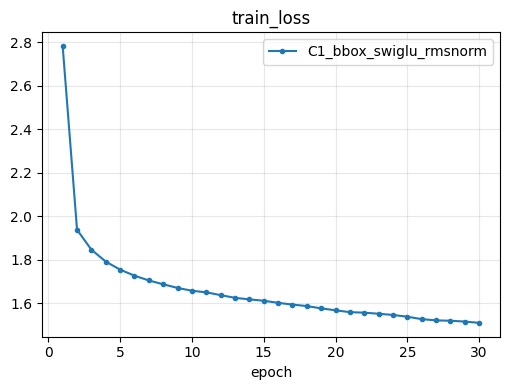

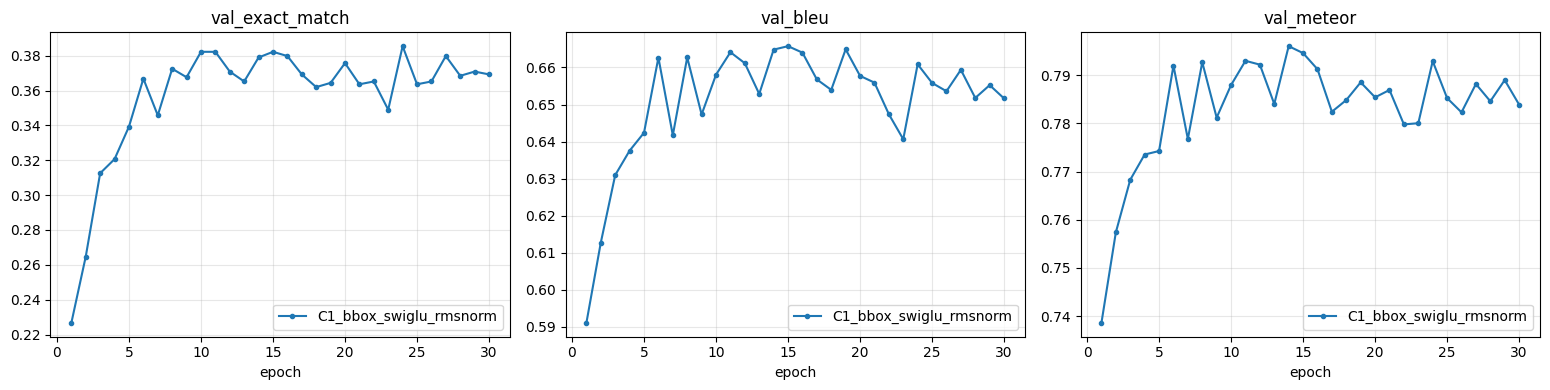

In [13]:
def plot_compare(histories, keys, title_prefix=''):
    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, key in zip(axes, keys):
        for tag, h in histories.items():
            ys = h['train_loss'] if key == 'train_loss' else h['val'].get(key, [])
            ax.plot(range(1, len(ys) + 1), ys, marker='o', markersize=3, label=tag)
        ax.set_title(f'{title_prefix}{key}')
        ax.set_xlabel('epoch')
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()


histories = {'C1_bbox_swiglu_rmsnorm': hist_C1}
plot_compare(histories, ['train_loss'])
plot_compare(histories, ['exact_match', 'bleu', 'meteor'], title_prefix='val_')

## 7. Đánh giá cuối trên test split

In [14]:
test_results = {}
for tag, model in [('C1_bbox_swiglu_rmsnorm', model_C1)]:
    ev = Evaluator(
        tokenizer=tokenizer, metrics=[ExactMatch(), BLEUScore(), METEORScore()],
        bos_id=_probe_cfg.bos_id, eos_id=_probe_cfg.eos_id, pad_id=_probe_cfg.pad_id,
        max_len=_probe_cfg.max_answer_len, beam_size=1,
    )
    test_results[tag] = ev.evaluate(model, test_loader)
    print(tag, test_results[tag])

C1_bbox_swiglu_rmsnorm {'exact_match': 0.3643724696356275, 'bleu': 0.6421878315509337, 'meteor': 0.7819533735121992}


## 8. Inspect 1 sample (autoregressive inference)

In [15]:
SAMPLE_IDX = 6

sample    = test_loader.dataset[SAMPLE_IDX]
img_feat  = sample['img_feat'].unsqueeze(0).to(DEVICE)
txt_feat  = sample['txt_feat'].unsqueeze(0).to(DEVICE)
txt_mask  = sample['txt_mask'].unsqueeze(0).to(DEVICE)
bbox_feat = sample['bbox_feat'].unsqueeze(0).to(DEVICE)
bbox_mask = sample['bbox_mask'].unsqueeze(0).to(DEVICE)
bbox_cls  = sample['bbox_cls'].unsqueeze(0).to(DEVICE)

print(f'Q: {sample["raw_question"]}')
print(f'A: {sample["raw_answer"]}')
print(f'bbox_cls: {sample["bbox_cls"].tolist()}  (1=con lan, 2=nguoi bieu dien, 0=pad)')
print()


def _decode_clean(ids, pad_id, bos_id, eos_id):
    out = []
    for t in ids:
        if t == eos_id: break
        if t in (pad_id, bos_id): continue
        out.append(int(t))
    return tokenizer.decode(out, skip_special_tokens=True).strip()


model_C1.eval()
with torch.no_grad():
    pred_ids = model_C1.generate(
        img_feat=img_feat, txt_feat=txt_feat, txt_mask=txt_mask,
        bbox_feat=bbox_feat, bbox_mask=bbox_mask, bbox_cls=bbox_cls,
        bos_id=_probe_cfg.bos_id, eos_id=_probe_cfg.eos_id,
        max_len=_probe_cfg.max_answer_len, beam_size=1,
    )[0].cpu().tolist()

pred = _decode_clean(pred_ids, _probe_cfg.pad_id, _probe_cfg.bos_id, _probe_cfg.eos_id)
print(f'[C1_bbox_swiglu_rmsnorm] {pred}')

Q: Màu sắc của sừng con lân trong hình là gì?
A: Sừng con lân có màu vàng và đỏ.
bbox_cls: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  (1=con lan, 2=nguoi bieu dien, 0=pad)

[C1_bbox_swiglu_rmsnorm] Sừng con lân có màu vàng.


## 9. Lưu lại history + test results

In [16]:
summary_path = os.path.join(HIST_DIR, 'train_eval_C_history.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump({'history': histories, 'test': test_results}, f, ensure_ascii=False, indent=2)
print('saved ->', summary_path)

saved -> /kaggle/working/logs/train_eval_C_history.json
